# Lab 6: Unsupervised Learning II - Dimensionality Reduction

In this lab, we will cover the following topics:
1. Dimensionality reduction techniques:
   * PCA
   * t-SNE
   * UMAP
2. Visualization and interpretation

Each section includes basic implementation and questions for further exploration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

C:\Users\Delwar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dimensionality Reduction

### 1.1 Principal Component Analysis (PCA)

We will start by implementing PCA for dimensionality reduction. We will also explore different parameters and visualize the results.

In [7]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

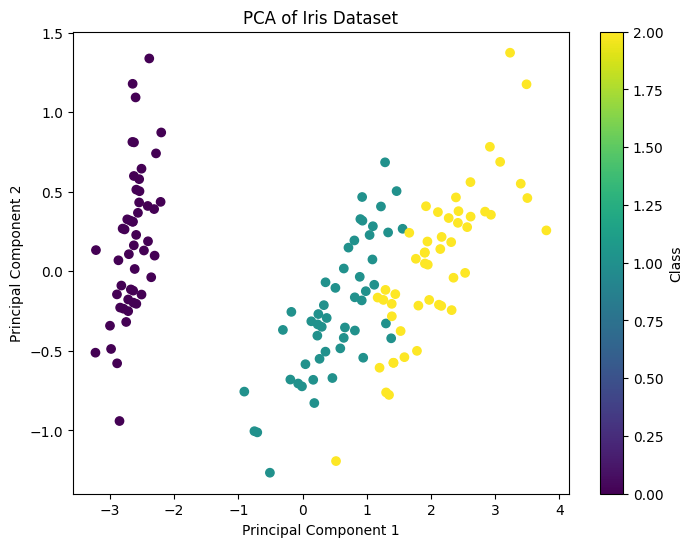

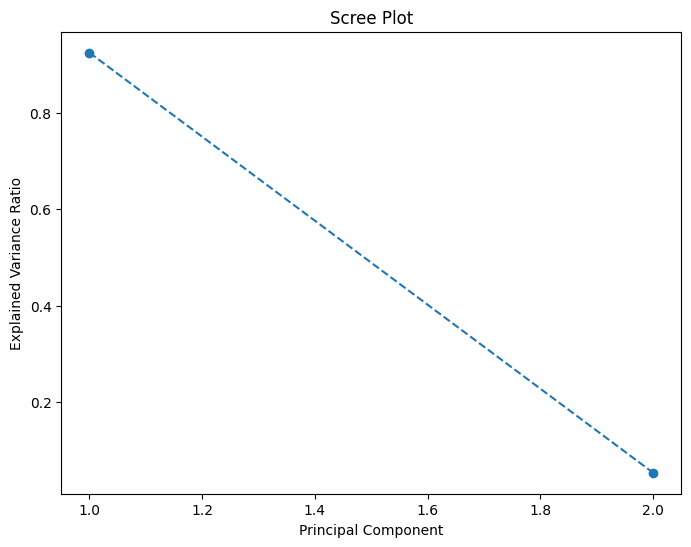

In [8]:
# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.colorbar(label='Class')
plt.show()

# Scree plot
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

### Questions for Exploration

1. How does changing the number of principal components (`n_components`) affect the explained variance ratio?
2. What happens to the visualization when you use more or fewer principal components?
3. How does the choice of dataset affect the PCA results and their interpretation?

### 1.2 t-Distributed Stochastic Neighbor Embedding (t-SNE)

Next, we will implement t-SNE for dimensionality reduction. We will also explore different parameters and visualize the results.

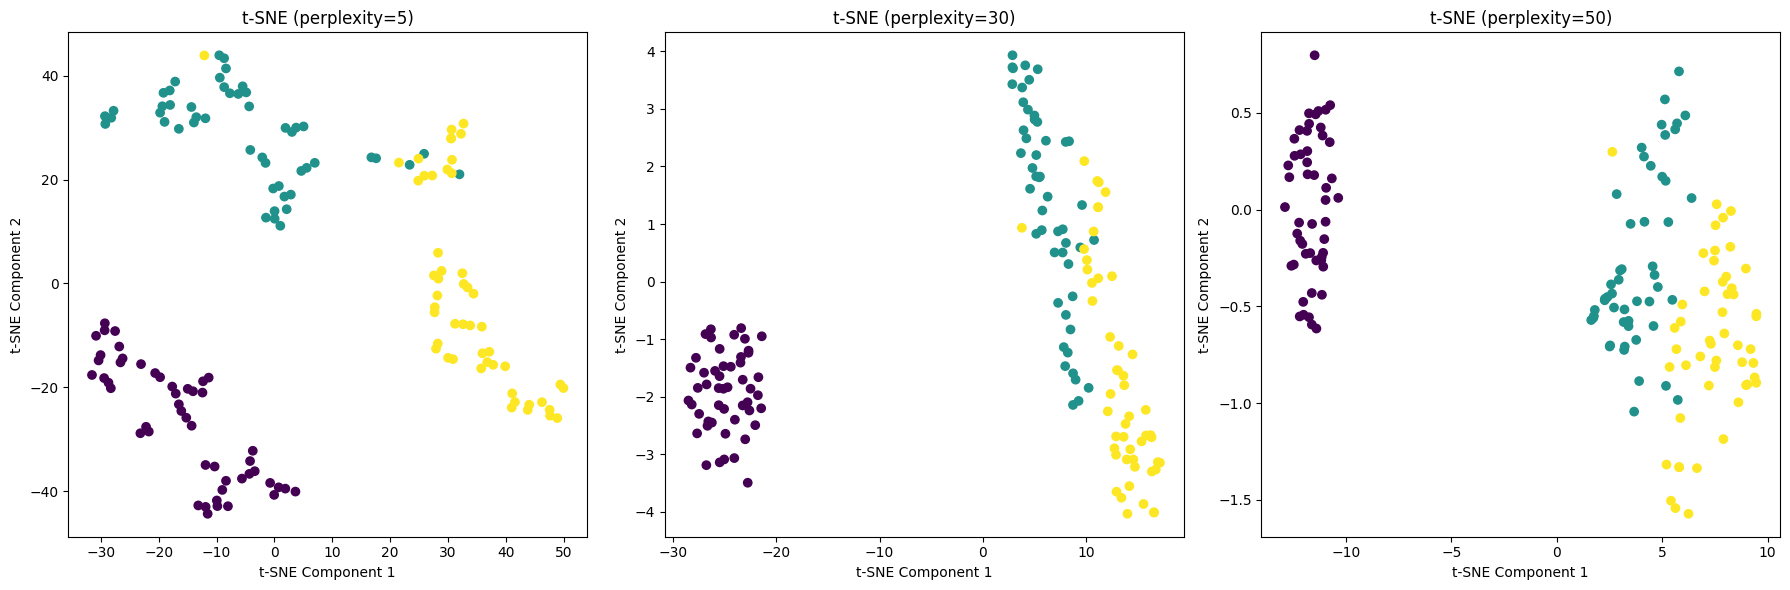

In [ ]:
# Perform t-SNE with different perplexity values
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 6))

for i, perplexity in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis')
    axes[i].set_title(f't-SNE (perplexity={perplexity})')
    axes[i].set_xlabel('t-SNE Component 1')
    axes[i].set_ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()


### Questions for Exploration

1. How does changing the perplexity parameter affect the t-SNE visualization?
2. What happens to the visualization when you change the learning rate?
3. How does the choice of dataset affect the t-SNE results and their interpretation?

### 1.3 Uniform Manifold Approximation and Projection (UMAP)

Finally, we will implement UMAP for dimensionality reduction. We will also explore different parameters and visualize the results.

In [ ]:
umap.UMAP?

C:\Users\Delwar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Init signature:
umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric='euclidean',
    metric_kwds=None,
    output_metric='euclidean',
    output_metric_kwds=None,
    n_epochs=None,
    learning_rate=1.0,
    init='spectral',
    min_dist=0.1,
    spread=1.0,
    low_memory=True,
    n_jobs=-1,
    set_op_mix_ratio=1.0,
    local_connectivity=1.0,
    repulsion_strength=1.0,
    negative_sample_rate=5,
    transform_queue_size=4.0,
    a=None,
    b=None,
    random_state=None,
    angular_rp_forest=False,
    target_n_neighbors=-1,
    target_metric='categorical',
    target_metric_kwds=None,
    target_weight=0.5,
    transform_seed=42,
    transform_mode='embedding',
    force_approximation_algorithm=False,
    verbose=False,
    tqdm_kwds=None,
    unique=False,
    densmap=False,
    dens_lambda=2.0,
    dens_frac=0.3,
    dens_var_shift=0.1,
    output_dens=False,
    disconnection_distance=None,
    precomputed_knn=(None, None, None),
)
Docstring:     
Uniform Manifold

C:\Users\Delwar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Delwar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Delwar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


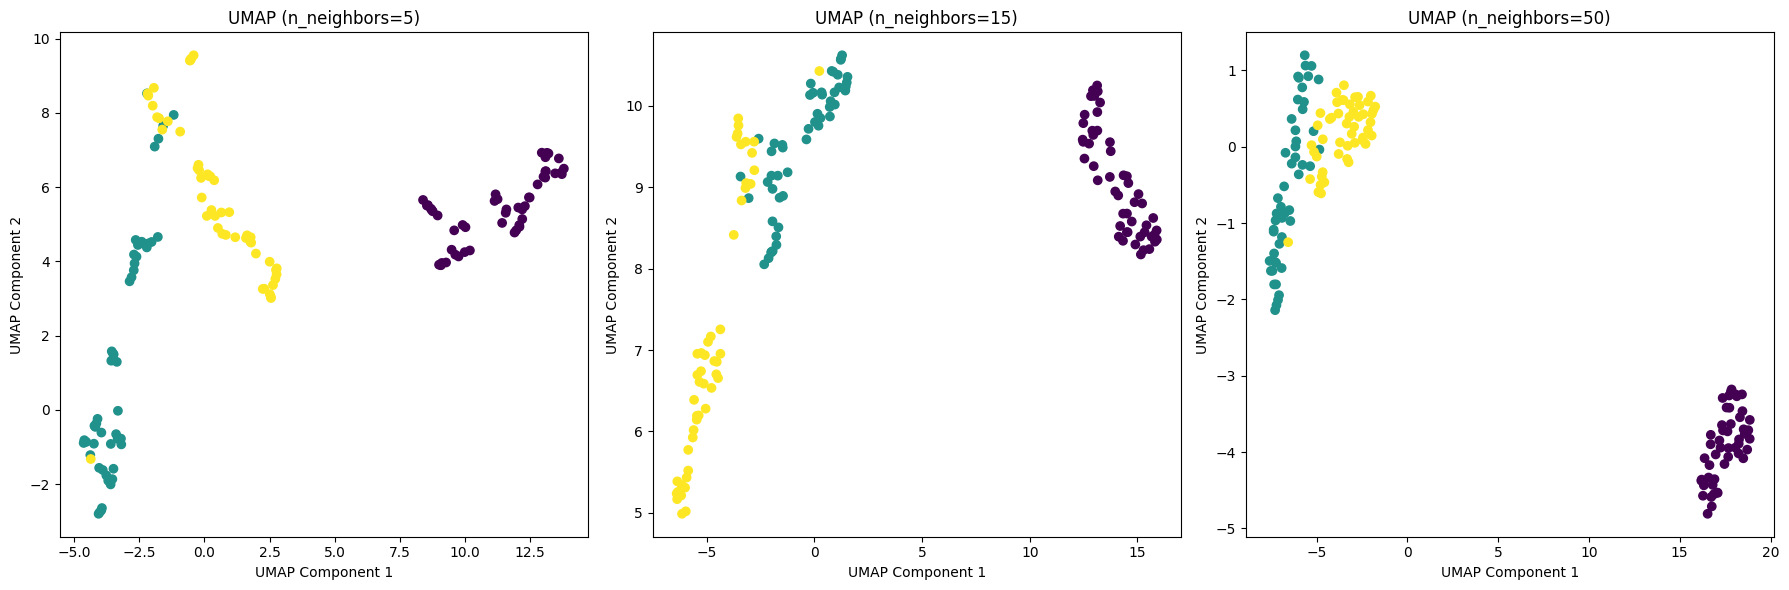

In [11]:
# Perform UMAP with different n_neighbors values
n_neighbors_values = [5, 15, 50]
fig, axes = plt.subplots(1, len(n_neighbors_values), figsize=(18, 6))

for i, n_neighbors in enumerate(n_neighbors_values):
    umap_reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42)
    X_umap = umap_reducer.fit_transform(X)
    axes[i].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='viridis')
    axes[i].set_title(f'UMAP (n_neighbors={n_neighbors})')
    axes[i].set_xlabel('UMAP Component 1')
    axes[i].set_ylabel('UMAP Component 2')

plt.tight_layout()
plt.show()


### Questions for Exploration

1. How does changing the number of neighbors (`n_neighbors`) affect the UMAP visualization?
2. What happens to the visualization when you change the minimum distance (`min_dist`)?
3. How does the choice of dataset affect the UMAP results and their interpretation?

## 2. Visualization and Interpretation

We will visualize and interpret the results of different dimensionality reduction techniques. We will also explore different visualization techniques.

C:\Users\Delwar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


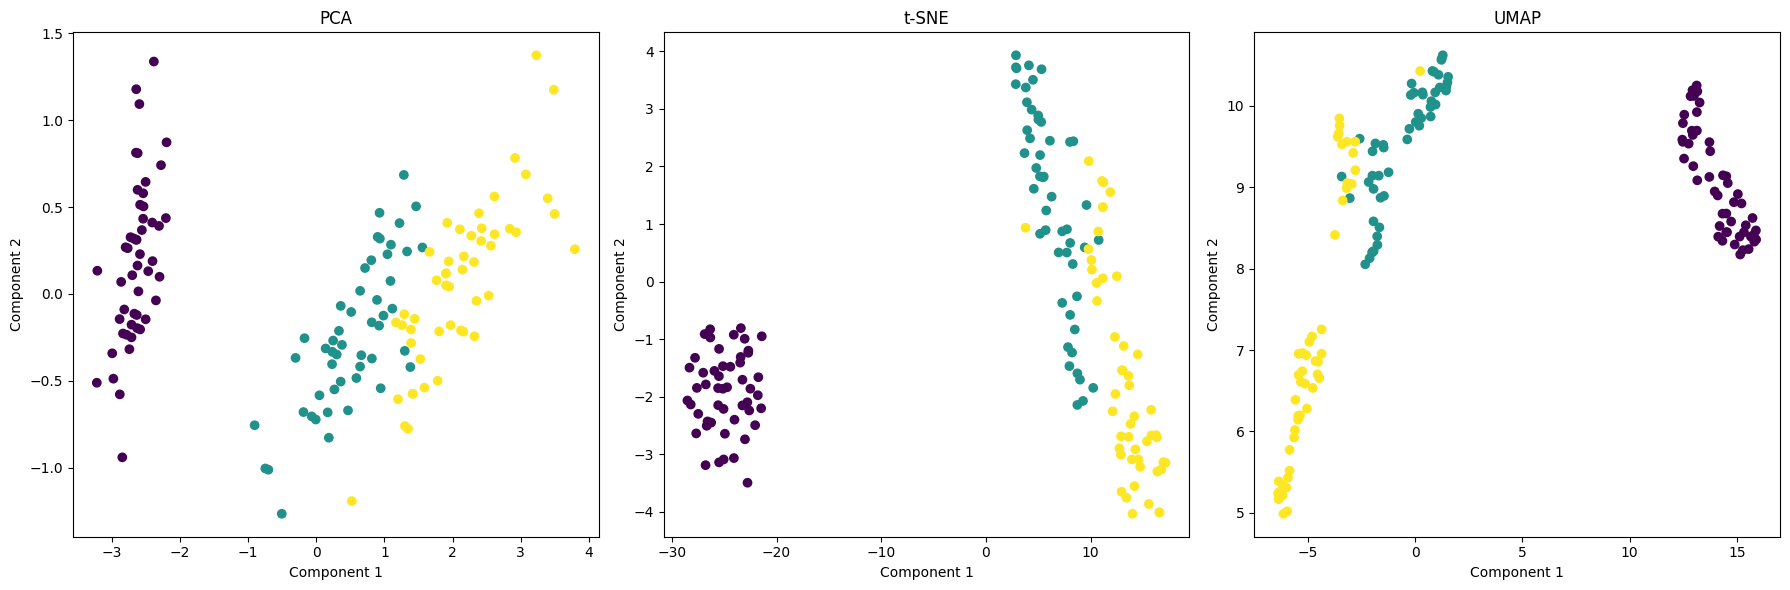

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Perform UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X)

# Plot the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
axes[0].set_title('PCA')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis')
axes[1].set_title('t-SNE')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='viridis')
axes[2].set_title('UMAP')
axes[2].set_xlabel('Component 1')
axes[2].set_ylabel('Component 2')

plt.tight_layout()
plt.show()


### Questions for Exploration

1. How do the visualizations of PCA, t-SNE, and UMAP compare?
2. What are the strengths and weaknesses of each dimensionality reduction technique?
3. How does the choice of parameters affect the visualization and interpretation of each technique?

## Extensions

1. Apply clustering algorithms (e.g., k-Means) on the reduced dimensions obtained from PCA, t-SNE, and UMAP.
    * How do the clustering results compare when using different dimensionality reduction techniques?
2. Use quantitative metrics (e.g., trustworthiness, continuity) to evaluate the quality of the dimensionality reduction.
    * How do PCA, t-SNE, and UMAP compare based on these metrics?
Handling High-Dimensional Data
3. Use PCA to reduce noise in a dataset by retaining only the top principal components.
    * How does this noise reduction affect the performance of downstream tasks (e.g., classification, clustering)?
4. Explore other dimensionality reduction techniques such as Independent Component Analysis (ICA), Linear Discriminant Analysis (LDA), and Isomap.
    * How do these techniques compare to PCA, t-SNE, and UMAP in terms of visualization and interpretation?

Performing dimentional reduction using Clinical dataset

In [2]:
from sklearn.impute import KNNImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Cleaning Datasets

In [3]:
import pandas as pd

# load the data
clinical = pd.read_csv('NSCLC Data/clinical.csv')
sequencing = pd.read_csv('NSCLC Data/tpm_counts.csv')

# 1. Remove columns that are missing TOO MUCH data
threshold_to_remove_column = 0.5
cols_to_drop = sequencing.columns[sequencing.isnull().mean() > threshold_to_remove_column]

sequencing.drop(columns=cols_to_drop, inplace=True)
# sequencing = sequencing.drop(cols_to_drop, axis=1) <-- depending on your version of Python

# 2. Impute missing values using KNN imputation
usubjid_rna = sequencing.copy()['Unnamed: 0']
sequencing_no_usubjid = sequencing.drop(columns=['Unnamed: 0'], axis=1)

imputer = KNNImputer(n_neighbors=5)
sequencing_imputed = imputer.fit_transform(sequencing_no_usubjid)

# 3. Isolate the clinical data that we actually have sequencing for
clinical_subset = clinical[clinical['Case ID'].isin(usubjid_rna)]

Export cleaned data into NSCLC Data folder

In [4]:
sequencing_clean = pd.DataFrame(sequencing_imputed, columns=sequencing_no_usubjid.columns)
sequencing_clean.insert(0,"Case ID",usubjid_rna)

sequencing_clean.to_csv('NSCLC Data/sequencing_clean.csv')
clinical_subset.to_csv('NSCLC Data/clinical_subset_w_biopsy.csv')

Perform Dimentional Reduction

[np.float64(0.4071434470123867), np.float64(0.5486123420374484), np.float64(0.6333606067747259), np.float64(0.6905415027970105), np.float64(0.7451525433907186), np.float64(0.7745120017853113), np.float64(0.7995133814224539), np.float64(0.821174798639895), np.float64(0.8424241390174521), np.float64(0.8613937461583838), np.float64(0.8777856024312328), np.float64(0.8938804117267279), np.float64(0.9071996007974562), np.float64(0.9184945107553389), np.float64(0.927434714747286), np.float64(0.9346722900173574), np.float64(0.9405133792216883), np.float64(0.9462543933128146), np.float64(0.9517900358258098), np.float64(0.9568591024708396), np.float64(0.9615820418322689), np.float64(0.9659279375128076), np.float64(0.9689698015166646), np.float64(0.9713112950123155), np.float64(0.9734467040361074), np.float64(0.9755201130146762), np.float64(0.9775447737206114), np.float64(0.9794532458652168), np.float64(0.9812758818952795), np.float64(0.982978035247418), np.float64(0.9846004869473688), np.float64

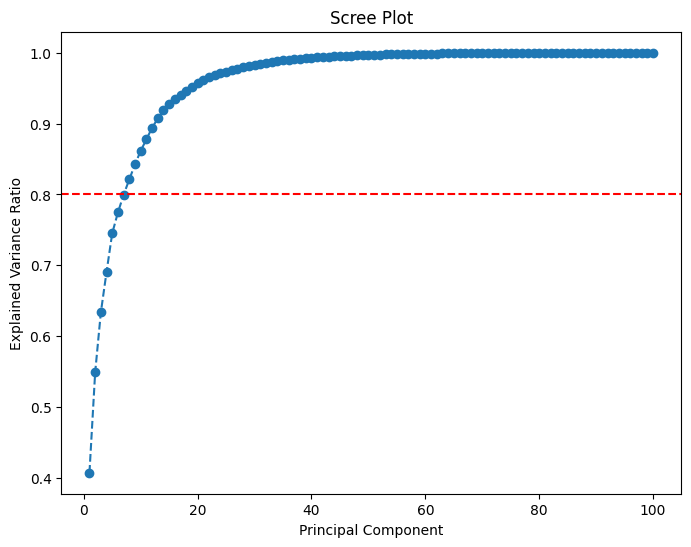

In [6]:
#Perform PCA
n=100
evr = []

for i in range(1,n+1):
    pca = PCA(n_components=i)
    sequencing_pca = pca.fit_transform(sequencing_imputed)
    evr.append(pca.explained_variance_ratio_.sum())

#Generating Skree plot, determine the number of PC that will capture 80% of variance
print(evr)
# Scree plot
# explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 6))
plt.plot(range(1, n+1), evr, marker='o', linestyle='--')
plt.axhline(y=0.8,color='r', linestyle='--', label='80% Variance Explained')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

FYI, 7 principal components are needed to capture 80% of the variance

In [ ]:
#t-Sine

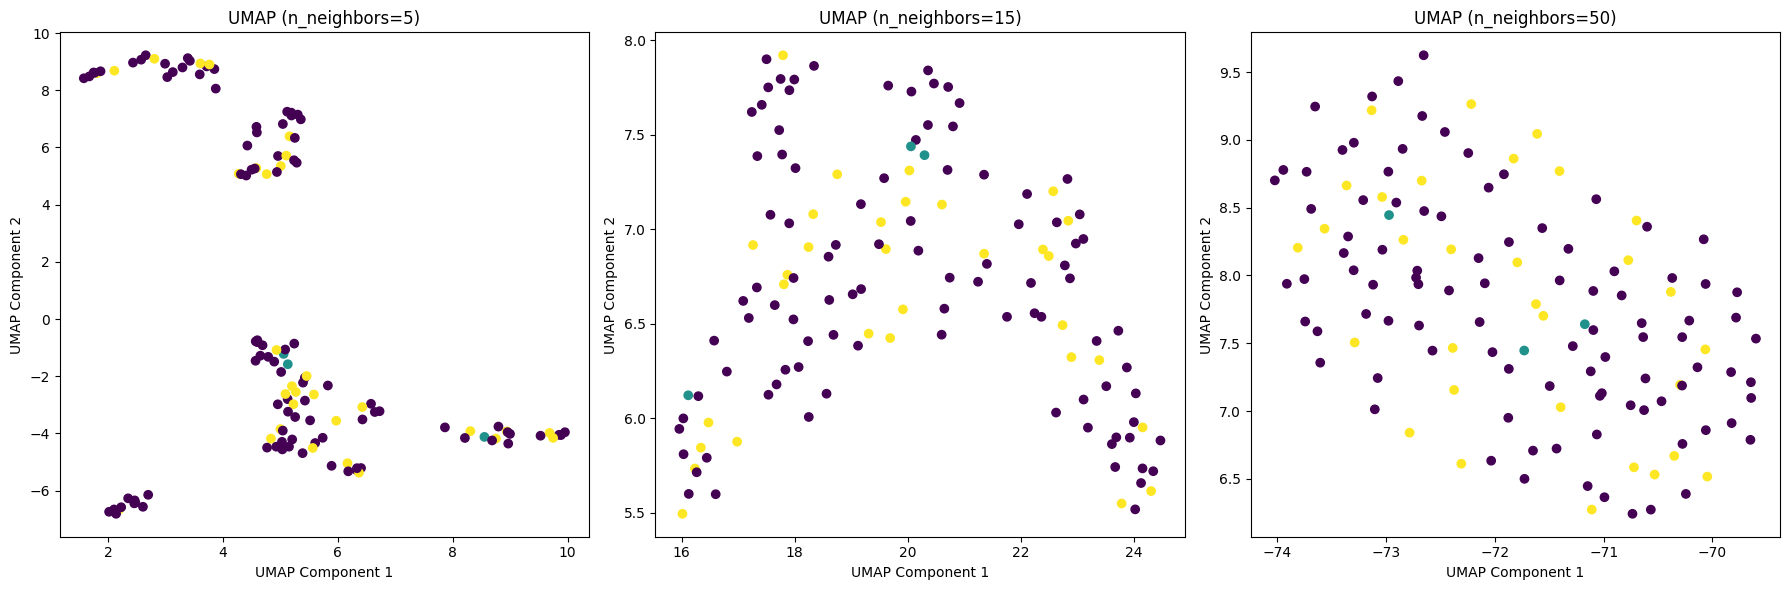

In [8]:
# define catigorical variables as numerical
clinical_characteristic = clinical_subset['Histology '].astype('category').cat.codes

n_neighbors_values = [5, 15, 50]
fig, axes = plt.subplots(1, len(n_neighbors_values), figsize=(18, 6))

for i, n_neighbors in enumerate(n_neighbors_values):
    umap_reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42, n_jobs=1)
    sequencing_umap = umap_reducer.fit_transform(sequencing_imputed)
    axes[i].scatter(sequencing_umap[:, 0], sequencing_umap[:, 1],c=clinical_characteristic,cmap='viridis')# c=[clinical characteristic], cmap='viridis'
    axes[i].set_title(f'UMAP (n_neighbors={n_neighbors})')
    axes[i].set_xlabel('UMAP Component 1')
    axes[i].set_ylabel('UMAP Component 2')

plt.tight_layout()
plt.show()